<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/CIFAR10_Dataset_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extract the data

In [7]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


Normalize Images


In [8]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


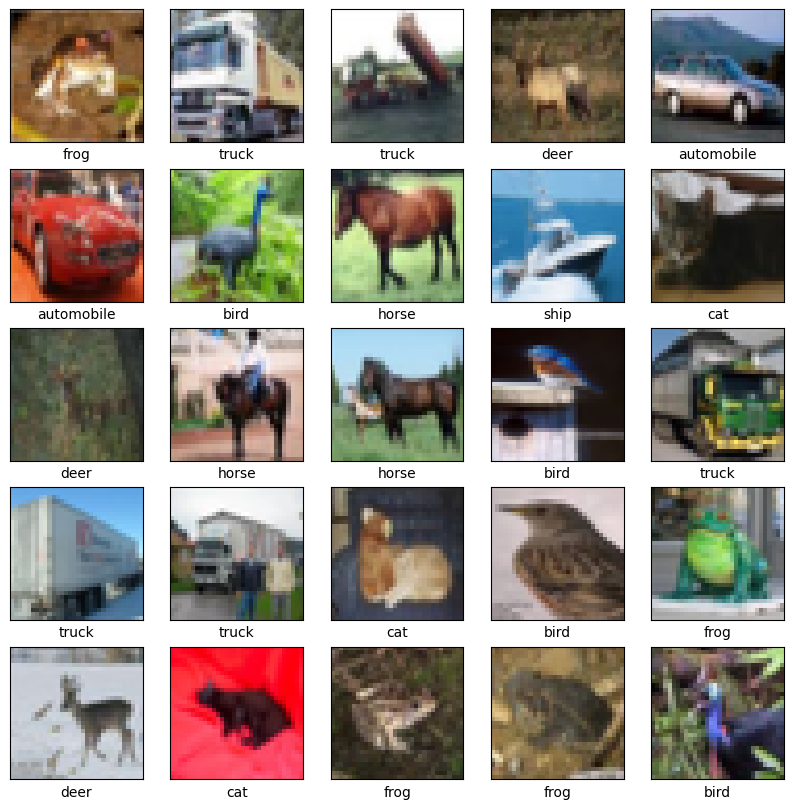

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


In [10]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [12]:
model = models.Sequential([
    # Convolution + Pooling layers
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [14]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.4520 - loss: 1.5002 - val_accuracy: 0.5421 - val_loss: 1.2727
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.6008 - loss: 1.1315 - val_accuracy: 0.6242 - val_loss: 1.0744
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6585 - loss: 0.9784 - val_accuracy: 0.6682 - val_loss: 0.9491
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.6960 - loss: 0.8736 - val_accuracy: 0.6771 - val_loss: 0.9334
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7243 - loss: 0.7929 - val_accuracy: 0.6910 - val_loss: 0.8858
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7445 - loss: 0.7340 - val_accuracy: 0.7066 - val_loss: 0.8501
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7628 - loss: 0.6818 - val_accuracy: 0.7090 - val_loss: 0.8668
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.7797 -

Evaluate Performance

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc)


313/313 - 5s - 16ms/step - accuracy: 0.7159 - loss: 0.9104
Test accuracy: 0.7159000039100647


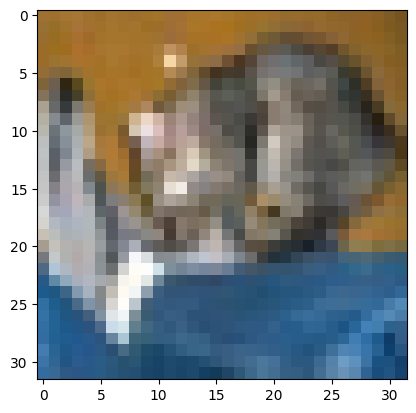

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Predicted label: cat
True label: cat


In [19]:
import numpy as np

# Pick one test image
img = x_test[0]
plt.imshow(img)
plt.show()

# Predict
pred = model.predict(img.reshape(1,32,32,3))
print("Predicted label:", class_names[np.argmax(pred)])
print("True label:", class_names[y_test[0][0]])


Plot Training Curves

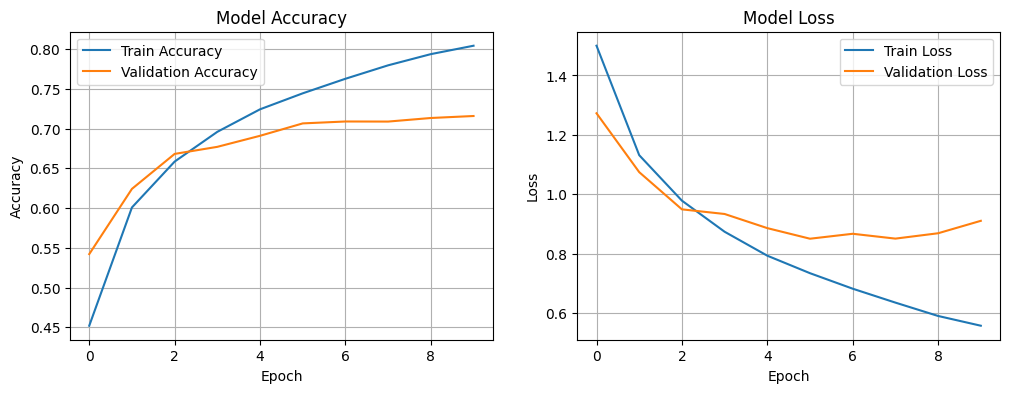

In [20]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


Shuffle Test Data

In [1]:
import numpy as np

# Shuffle test set
indices = np.arange(len(x_test))
np.random.shuffle(indices)

x_test_shuffled = x_test[indices]
y_test_shuffled = y_test[indices]


NameError: name 'x_test' is not defined

Transfer Learning Setup

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Resize CIFAR-10 images to 224x224
x_train_resized = tf.image.resize(x_train, [224,224])
x_test_resized = tf.image.resize(x_test_shuffled, [224,224])

# Preprocess for ResNet
x_train_resized = preprocess_input(x_train_resized)
x_test_resized = preprocess_input(x_test_resized)

# Load pretrained ResNet50 backbone
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(224,224,3))

# Freeze backbone
base_model.trainable = False


Build Transfer Learning Model

In [ ]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])


Train Transfer Learning Model

In [ ]:
history_transfer = transfer_model.fit(
    x_train_resized, y_train,
    epochs=5,
    validation_data=(x_test_resized, y_test_shuffled)
)


Predict on Shuffled Test Data

In [ ]:
preds = transfer_model.predict(x_test_resized[:10])  # predict first 10
for i in range(10):
    print("Predicted:", class_names[np.argmax(preds[i])],
          " | True:", class_names[y_test_shuffled[i][0]])
